<a href="https://colab.research.google.com/github/larscaspersen/phenoflex_meets_bayes/blob/main/hybridmodel_phenoflex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#!pip install -q numpyro==0.14.0 jax==0.4.26 jaxlib==0.4.26 arviz causalgraphicalmodels daft
!pip install -q numpyro jax jaxlib arviz causalgraphicalmodels daft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 MB 15.7 MB/s eta 0:00:00


In [4]:
# %%
import argparse
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import random
import jax.numpy as jnp
import arviz as az
import numpyro
from numpyro.contrib.control_flow import scan
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
# Building on numpyro AR2 example: https://num.pyro.ai/en/latest/examples/ar2.html
import pandas as pd

# **The standard phenoflex model in python**

Converted from c++ code with claude

I changed the values of E0, E1, A0 and A1 to standard dynamic model. in phenoflex they use the wrong default parameters

In [6]:
# ── Helper functions

#gdh model
def P1z(T: float, Tu: float, Tb: float, Tc: float) -> float:
    """GDH heat-accumulation rate (triangular bell, model 0)."""
    if Tb <= T <= Tu:
        return 0.5 * (1 + np.cos(np.pi + np.pi * (T - Tb) / (Tu - Tb)))
    elif Tu < T <= Tc:
        return 1 + np.cos(np.pi / 2 + np.pi / 2 * (T - Tu) / (Tc - Tu))
    return 0.0

 #alternative heat accumulation model
def P2z(T: float, Tu: float, Delta: float) -> float:
    """Gaussian heat-accumulation rate (model 1)."""
    return np.exp(-((T - Tu) / (2 * Delta)) ** 2)

#transition function (either PDBF to DBF or Py for effective heat accumulation)
def PFcn(T: float, Tf: float, slope: float) -> float:
    """Sigmoid that controls labile→stable chill conversion and heat sensitivity."""
    x = slope * Tf * (T - Tf) / T
    if x >= 17:
        return 1.0
    if x <= -20:
        return 0.0
    sr = np.exp(x)
    return sr / (1 + sr)


def phenoflex(
    temp,
    times,
    yc: float = 40.0,
    zc: float = 190.0,
    s1: float = 0.5,
    E0: float = 4153.5,
    E1: float = 12888.8,
    A0: float = 139500,
    A1: float = 2567000000000000000,
    Tf: float = 4.0,
    slope: float = 1.6,
    Tb: float = 4.0,
    Tu: float = 26.0,
    Tc: float = 36.0,
    Delta: float = 4.0,
    Imodel: int = 0,
    stopatzc: bool = True,
    deg_celsius: bool = True,
    basic_output: bool = True,
) -> dict:
    """
    Python translation of the PhenoFlex C++ / Rcpp model.

    Parameters
    ----------
    temp       : array-like of hourly temperatures
    times      : array-like of corresponding time stamps (hours)
    yc         : chill requirement (stable chill units)
    zc         : heat requirement (GDH or GDD units)
    s1         : slope of PFcn sigmoid for heat sensitivity
    E0, E1     : activation energies for chill pool dynamics
    A0, A1     : pre-exponential factors for chill pool dynamics
    Tf         : base temperature for labile-to-stable chill conversion (°C)
    slope      : steepness of the labile-to-stable sigmoid
    Tb, Tu, Tc : base, optimum, ceiling temperatures for heat model 0 (°C)
    Delta      : half-width for Gaussian heat model 1 (°C)
    Imodel     : 0 = GDH triangular bell, 1 = Gaussian
    stopatzc   : stop simulation once zc is reached
    deg_celsius: True if temperatures are in °C (will be converted to K internally)
    basic_output: True → return only bloomindex; False → return full state arrays

    Returns
    -------
    dict with 'bloomindex' (and optionally 'x', 'y', 'z', 'xs')
    """
    temp = np.asarray(temp, dtype=float)
    times = np.asarray(times, dtype=float)
    N = len(temp)

    x = np.zeros(N)   # labile chill pool
    y = np.zeros(N)   # stable chill pool
    z = np.zeros(N)   # accumulated heat
    xs = np.zeros(N)  # equilibrium labile chill

    # Convert threshold temperatures to Kelvin if needed
    _Tf = Tf + 273.0 if deg_celsius else Tf
    _Tu = Tu + 273.0 if deg_celsius else Tu
    _Tc = Tc + 273.0 if deg_celsius else Tc
    _Tb = Tb + 273.0 if deg_celsius else Tb

    bloomindex = 0

    for i in range(N - 1):
        ti = temp[i] + 273.0 if deg_celsius else temp[i]
        dt = times[i + 1] - times[i]

        # Equilibrium labile chill and rate constant
        xs[i] = A0 / A1 * np.exp(-(E0 - E1) / ti)
        k1 = A1 * np.exp(-E1 / ti)

        # Update labile chill pool (exponential relaxation toward equilibrium)
        x[i + 1] = xs[i] - (xs[i] - x[i]) * np.exp(-k1 * dt)

        # Carry stable chill forward (only modified below if x >= 1)
        y[i + 1] = y[i]

        # Accumulate heat
        if Imodel == 0:
            z[i + 1] = z[i] + P1z(ti, _Tu, _Tb, _Tc) * PFcn(y[i], yc, s1) * dt
        else:
            z[i + 1] = z[i] + P2z(ti, _Tu, Delta) * PFcn(y[i], yc, s1) * dt

        # Convert labile to stable chill when pool is saturated
        if x[i + 1] >= 1.0:
            delta = PFcn(ti, _Tf, slope) * x[i + 1]
            y[i + 1] += delta
            x[i + 1] -= delta

        # Check heat requirement
        if z[i + 1] >= zc:
            bloomindex = i + 2  # +2 for Fortran/R 1-based index convention
            if stopatzc:
                break

    if basic_output:
        return {"bloomindex": bloomindex}
    return {"x": x, "y": y, "z": z, "xs": xs, "bloomindex": bloomindex}

Example data from the chillR package

In [7]:
#read example files
url = "https://raw.githubusercontent.com/larscaspersen/phenoflex_meets_bayes/refs/heads/main/KA_bloom.csv"
KA_bloom = pd.read_csv(url)

KA_temp_hourly = pd.read_csv("https://raw.githubusercontent.com/larscaspersen/phenoflex_meets_bayes/refs/heads/main/KA_hourtemps.csv")

KA_temp_hourly.head()

,Year,Month,Day,Tmax,Tmin,JDay,Hour,Temp
0,1998,1,1,8.2,5.1,1,0,5.1
1,1998,1,1,8.2,5.1,1,1,5.1
2,1998,1,1,8.2,5.1,1,2,5.1
3,1998,1,1,8.2,5.1,1,3,5.1
4,1998,1,1,8.2,5.1,1,4,5.1


In [8]:
#taken from ChatGPT
def gen_season_list(temps, mrange=(8, 6), years=None):
    """
    Python equivalent of chillR::genSeasonList

    Parameters:
        temps (pd.DataFrame): Must contain columns ['Year', 'Month', 'Temp', 'JDay']
        mrange (tuple): (start_month, end_month), e.g. (8, 6)
        years (list or iterable): Years to generate seasons for

    Returns:
        list of pd.DataFrame
    """

    assert len(mrange) == 2, "mrange must have length 2"
    assert years is not None, "years must be provided"
    assert temps is not None, "temps must be provided"
    assert mrange[0] > mrange[1], "start month must be greater than end month"

    start_month, end_month = mrange
    season_list = []

    for y in years:
        # Previous year portion (start_month → Dec)
        prev_mask = (
            (temps["Month"].between(start_month, 12)) &
            (temps["Year"] == y - 1)
        )

        # Current year portion (Jan → end_month)
        curr_mask = (
            (temps["Month"].between(1, end_month)) &
            (temps["Year"] == y)
        )

        season_df = temps.loc[prev_mask | curr_mask, ["Temp", "JDay", "Year"]].copy()

        season_list.append(season_df)

    return season_list

Test the python version of PhenoFkex

In [9]:
example_season = gen_season_list(KA_temp_hourly, years = [2000])

# Create a times vector of the same length as Temp, with sequential integers starting from 0
season_length = len(example_season[0].Temp)
times_vector = jnp.arange(season_length)

example_season[0].head()

#test example season with phenoflex model
test = phenoflex(temp = example_season[0].Temp, times=times_vector,
                 basic_output=False)

/tmp/ipykernel_2676/182225480.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  x = slope * Tf * (T - Tf) / T


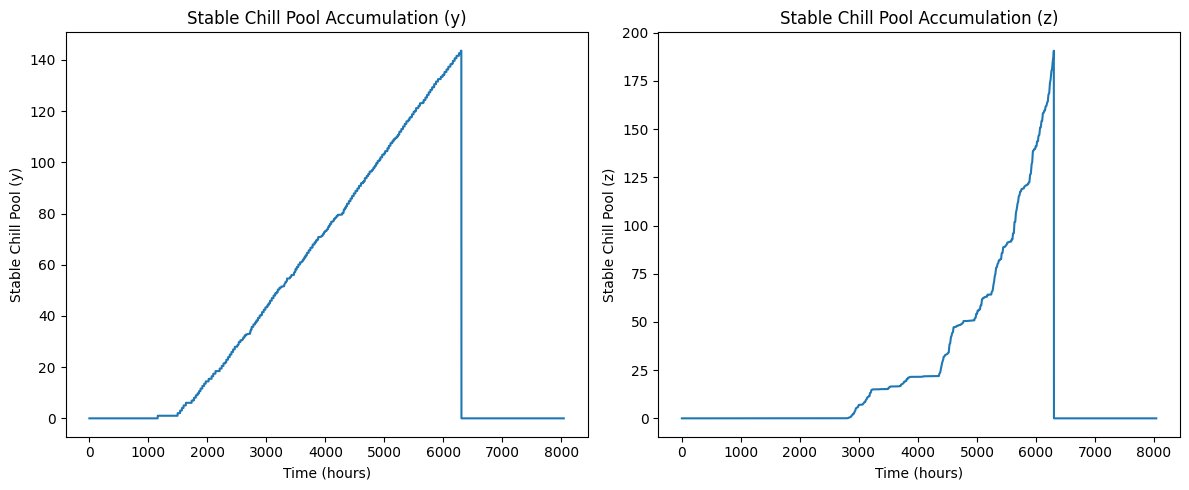

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First plot (y)
axes[0].plot(test['y'])
axes[0].set_xlabel('Time (hours)')
axes[0].set_ylabel('Stable Chill Pool (y)')
axes[0].set_title('Stable Chill Pool Accumulation (y)')

# Second plot (z)
axes[1].plot(test['z'])
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Stable Chill Pool (z)')
axes[1].set_title('Stable Chill Pool Accumulation (z)')

plt.tight_layout()
plt.show()

In [12]:
test['bloomindex']

6304

Output the same as in R :)

In [13]:
phenoflex(temp = example_season[0].Temp, times=times_vector,
                 basic_output=True)

/tmp/ipykernel_2676/182225480.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  x = slope * Tf * (T - Tf) / T


{'bloomindex': 6304}

# **PhenoFlex for Numpyro**

The cases in PhenoFlex where coded with jnp.where (e.g. when we check for temperature thresholds or when we check for the 1.0 threshold for conversion)

In addition a smooth bloom date is returned with a function expressing the difference to heat requirement. When accumulated heat is too low or exceed the threshold too much, then it is penalized. I need to penalize too high heat aswell, otherwise the function is waiting until the difference is maximized


In [73]:
# ── JAX helpers (vectorised, no Python loops) ─────────────────────────────────

def _p1z_jax(T, Tu, Tb, Tc):
    in_lower = (T >= Tb) & (T <= Tu)
    in_upper = (T > Tu) & (T <= Tc)
    val_lower = 0.5 * (1 + jnp.cos(jnp.pi + jnp.pi * (T - Tb) / (Tu - Tb)))
    val_upper = 1 + jnp.cos(jnp.pi / 2 + jnp.pi / 2 * (T - Tu) / (Tc - Tu))
    return jnp.where(in_lower, val_lower, jnp.where(in_upper, val_upper, 0.0))

def _p2z_jax(T, Tu, Delta):
    return jnp.exp(-((T - Tu) / (2 * Delta)) ** 2)

def _pfcn_jax(T, Tf, slope):
   # Guard against T=0 (occurs at season start when y_prev=0)
    T_safe = jnp.where(T == 0.0, 1.0, T)  # safe value for division; masked out below
    x = slope * Tf * (T_safe - Tf) / T_safe
    sr = jnp.exp(jnp.clip(x, -20, 17))
    result = jnp.where(x >= 17, 1.0, jnp.where(x <= -20, 0.0, sr / (1 + sr)))
    return jnp.where(T == 0.0, 0.0, result)  # when y=0, no forcing

    #x = slope * Tf * (T - Tf) / T
    #sr = jnp.exp(jnp.clip(x, -20, 17))
    #return jnp.where(x >= 17, 1.0, jnp.where(x <= -20, 0.0, sr / (1 + sr)))

# ── Soft bloom-date estimator ─────────────────────────────────────────────────

def soft_bloom_hour(z_trace, hours, zc, sharpness=1.0):
    """
    Differentiable approximation of the hour at which z first crosses zc.

    A hard argmax is not differentiable, so we use a softmax over (z - zc).
    As sharpness -> inf this converges to the true crossing point.
    Values of 0.5–2.0 work well in practice.

    Parameters
    ----------
    z_trace   : jnp array (N-1,) — accumulated heat at each time step
    hours     : jnp array (N-1,) — hours[i] is the time at which z_trace[i] was computed
    zc        : heat requirement threshold (scalar, can be a sampled parameter)
    sharpness : controls how peaked the soft-argmax is

    Returns
    -------
    Scalar: differentiable estimate of the bloom hour
    """
    #logits  = sharpness * (z_trace - zc)
    #this favpours to wait forever, until the difference is maxed.
    #this is ALWAYS at the end of the time series

    # MODIFIED: Use negative squared difference for logits
    logits  = -sharpness * (z_trace - zc)**2

    #new approach: negative bi
    # Numerically stable softmax
    logits  = logits - jnp.max(logits, axis=-1, keepdims=True)
    weights = jnp.exp(logits)
    weights = weights / jnp.sum(weights, axis=-1, keepdims=True)
    return jnp.sum(weights * hours, axis=-1) # Use sum instead of dot for batched operation

# ── Numpyro model ─────────────────────────────────────────────────────────────

def phenoflex_numpyro(
    temp,
    times,
    bloom_doy_obs=None,
    start_doy=0.0,
    Imodel=0,
    deg_celsius=True,
    sharpness=1.0,
    leap_years = None,
    return_traces=False, # New flag for conditional return
):
    """
    Numpyro probabilistic wrapper around PhenoFlex.

    The forward pass accumulates heat (z) over the season. The predicted bloom
    date is the hour at which z crosses zc, converted to day-of-year via
    start_doy. Because argmax is not differentiable we use soft_bloom_hour()
    as a smooth approximation.

    Parameters
    ----------
    temp          : jnp array of hourly temperatures, length N or (num_seasons, N)
    times         : jnp array of hours since season start, length N or (num_seasons, N)
                    e.g. [0, 1, 2, ..., N-1] for consecutive hourly records
    bloom_doy_obs : observed bloom date as day-of-year (scalar or 1-D array
                    if multiple years are handled outside this function).
                    Pass None for prior predictive / generative mode.
    start_doy     : day-of-year corresponding to times[0].
                    E.g. if the season starts on Nov 1 = DOY 305, pass 305.
    Imodel        : 0 = GDH triangular bell, 1 = Gaussian
    deg_celsius   : True if temperatures arrive in Celsius
    sharpness     : steepness of the soft bloom-date estimator.
                    Increase if the posterior is diffuse; decrease if gradients vanish.
    leap_years    : either none or vector of boolean, indicating if it is a leap year
    return_traces : If True, x_trace, y_trace, and z_trace will be returned as deterministic outputs.
    """

    # ── Priors ────────────────────────────────────────────────────────────────
    yc    = numpyro.sample("yc",    dist.Normal(65.0,  10.0))
    zc    = numpyro.sample("zc",    dist.Normal(220.0, 30.0))
    s1    = numpyro.sample("s1",    dist.Beta(2.0, 2.0))
    E0    = numpyro.sample("E0",    dist.Normal(4153.5, 200.0))
    E1    = numpyro.sample("E1",    dist.Normal(12888.8, 500.0))
    A0    = numpyro.sample("A0",    dist.HalfNormal(139500)) # Changed to HalfNormal as values are positive
    A1    = numpyro.sample("A1",    dist.HalfNormal(2.567e18)) # Changed to HalfNormal
    Tf    = numpyro.sample("Tf",    dist.Normal(4.0,   1.0))
    slope = numpyro.sample("slope", dist.HalfNormal(1.6))
    Tb    = numpyro.sample("Tb",    dist.Normal(4.0,   2.0))
    Tu    = numpyro.sample("Tu",    dist.Normal(26.0,  3.0))
    Tc    = numpyro.sample("Tc",    dist.Normal(36.0,  3.0))
    Delta = numpyro.sample("Delta", dist.HalfNormal(5.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(3.0))  # days (shared observation noise)

    # Ensure temp and times are at least 1D arrays, and if they are single season, make them 2D
    if temp.ndim == 1:
        temp = temp[None, :]
        times = times[None, :]
        if bloom_doy_obs is not None: # only make obs 1D if it's not None
            bloom_doy_obs = bloom_doy_obs[None]
        start_doy = start_doy[None]
        # If leap_years is a single boolean, convert it to a 1-element array for consistency
        if leap_years is not None and jnp.ndim(jnp.asarray(leap_years)) == 0:
            leap_years = jnp.asarray([leap_years]) # Convert to 1-element array

    num_seasons = temp.shape[0]

    # Determine days_in_year_per_season (vector of 365.0 or 366.0 for each season)
    if leap_years is None:
        days_in_year_per_season = jnp.full(num_seasons, 365.0)
    else:
        # Ensure leap_years is a JAX array for jnp.ndim to work correctly
        _leap_years_arr = jnp.asarray(leap_years)
        if jnp.ndim(_leap_years_arr) == 0:  # Single boolean value
            days_in_year_scalar = jnp.where(_leap_years_arr, 366.0, 365.0)
            days_in_year_per_season = jnp.full(num_seasons, days_in_year_scalar)
        else:  # Array of boolean values
            if _leap_years_arr.shape[0] != num_seasons:
                raise ValueError("Length of 'leap_years' must match 'num_seasons' or be a single boolean.")
            days_in_year_per_season = jnp.where(_leap_years_arr, 366.0, 365.0)

    # Convert threshold temperatures to Kelvin
    offset = 273.0 if deg_celsius else 0.0
    _Tf = Tf + offset
    _Tu = Tu + offset
    _Tc = Tc + offset
    _Tb = Tb + offset

    # The plate is not needed here as scan already handles the batching over seasons.
    # The 'plate' will be implicitly handled by NumPyro's vmap when `bloom_doy_obs` is provided as a batch.
    # with numpyro.plate("seasons", num_seasons):
    # ── Forward pass via scan ─────────────────────────────────────────────────
    # dt will be (num_seasons, N-1)
    dt = times[:, 1:] - times[:, :-1]

    def transition(carry, inputs):
        x_prev, y_prev, z_prev = carry
        ti_raw, dt_i = inputs # ti_raw and dt_i are now (num_seasons,)

        ti = ti_raw + offset

        # Ensure A0, A1, E0, E1, etc. are broadcastable if they are scalars from priors
        xs_i = A0 / A1 * jnp.exp(-(E0 - E1) / ti)
        k1   = A1 * jnp.exp(-E1 / ti)

        x_new = xs_i - (xs_i - x_prev) * jnp.exp(-k1 * dt_i)
        y_new = y_prev

        heat_rate = _p1z_jax(ti, _Tu, _Tb, _Tc) if Imodel == 0 else _p2z_jax(ti, _Tu, Delta)
        z_new = z_prev + heat_rate * _pfcn_jax(y_prev, yc, s1) * dt_i

        # Labile -> stable chill conversion
        delta   = _pfcn_jax(ti, _Tf, slope) * x_new
        convert = jnp.where(x_new >= 1.0, 1.0, 0.0)
        y_new   = y_new + convert * delta
        x_new   = x_new - convert * delta

        return (x_new, y_new, z_new), (x_new, y_new, z_new) # Return all states to be traced

    # Initial state for each season is (num_seasons,)
    init   = (jnp.zeros(num_seasons), jnp.zeros(num_seasons), jnp.zeros(num_seasons))
    # Inputs for scan need to be (num_time_steps, num_seasons) if we want to iterate over time
    # So we transpose temp[:, :-1] and dt
    inputs = (temp[:, :-1].T, dt.T)

    (_, _, _), (x_trace, y_trace, z_trace) = scan(transition, init, inputs)
    # x_trace, y_trace, z_trace will be (num_time_steps, num_seasons)
    # We want them back as (num_seasons, num_time_steps)
    x_trace = x_trace.T
    y_trace = y_trace.T
    z_trace = z_trace.T

    if return_traces:
        numpyro.deterministic("x_trace", x_trace)
        numpyro.deterministic("y_trace", y_trace)
        numpyro.deterministic("z_trace", z_trace)

    # ── Predicted bloom date ──────────────────────────────────────────────────
    # times[:, 1:] are the hours at which each z value was recorded, (num_seasons, N-1)
    # z_trace is (num_seasons, N-1)
    # zc is scalar, but will broadcast correctly
    bloom_hour     = soft_bloom_hour(z_trace, times[:, 1:], zc, sharpness=sharpness)
    #temperature time series usually start at midnight, doy is centered on midday
    #raw_bloom_doy_pred = (start_doy-0.5) + (bloom_hour / 24.0) - 0.5
    bloom_doy_pred = (start_doy-0.5-days_in_year_per_season) + (bloom_hour / 24.0) - 0.5

    #bloom_doy_pred = numpyro.deterministic(
    #    "bloom_doy_pred",
    #    jnp.where(raw_bloom_doy_pred > days_in_year_per_season, raw_bloom_doy_pred - days_in_year_per_season, raw_bloom_doy_pred)
    #)

    # ── Observation noise ─────────────────────────────────────────────────────
    # Bloom phenology observations carry real uncertainty from observer error,
    # the definition of first-flower, spatial variability, etc.
    # A few days of SD is typical for field phenology data.
    # sigma is defined outside the plate, so it's shared.

    # ── Likelihood ────────────────────────────────────────────────────────────
    if bloom_doy_obs is not None:
        # Inference mode: condition on observed bloom date
        numpyro.sample("bloom_doy", dist.Normal(bloom_doy_pred, sigma), obs=bloom_doy_obs)


In [38]:
# Helpers ───────────────────────────────────────────────────────────────────

def gen_season_list(temps, mrange=(8, 6), years=None):
    """Python equivalent of chillR::genSeasonList."""
    assert len(mrange) == 2 and mrange[0] > mrange[1]
    assert years is not None and temps is not None
    start_month, end_month = mrange

    return [
        temps.loc[
            ((temps["Month"].between(start_month, 12)) & (temps["Year"] == y - 1)) |
            ((temps["Month"].between(1, end_month))    & (temps["Year"] == y)),
            ["Temp", "JDay", "Year"]
        ].copy()
        for y in years
    ]


def check_leap_year(years):
    y = np.asarray(years)
    return (y % 4 == 0) & ((y % 100 != 0) | (y % 400 == 0))


def prepare_seasons(season_list, bloom_df, years):
    """
    Pad seasons to a common length and return stacked JAX arrays
    ready to pass into phenoflex_numpyro.

    Returns
    -------
    temps      : (S, T) float32
    times      : (S, T) float32
    start_doys : (S,)   float32
    bloom_doys : (S,)   float32
    leap_years : (S,)   bool
    """
    # Ensure season_list and years have consistent lengths
    if len(season_list) != len(years):
        raise ValueError(
            f"The `season_list` must contain one entry for each year in the `years` argument. "
            f"Expected {len(years)} seasons, but got {len(season_list)}."
        )

    # Check for empty season dataframes
    for i, season_df in enumerate(season_list):
        if season_df.empty:
            raise ValueError(
                f"Season data for year {years[i]} is empty. This indicates a lack of temperature data for that season."
            )

    max_len = max(len(s) for s in season_list)
    if max_len == 0:
        raise ValueError("All seasons in `season_list` are empty. Cannot prepare data.")

    padded_temps, padded_times, start_doys = [], [], []

    for season_df in season_list:
        temp  = jnp.asarray(season_df.Temp.values, dtype=jnp.float32)
        times = jnp.arange(len(temp),              dtype=jnp.float32)
        pad   = max_len - len(temp)

        padded_temps.append(
            jnp.pad(temp,  (0, pad), mode="edge") if pad else temp
        )
        padded_times.append(
            jnp.concatenate([times, times[-1] + jnp.arange(1, pad + 1, dtype=jnp.float32)])
            if pad else times
        )

        first = season_df.iloc[0]
        hour_offset = (first["Hour"] / 24.0) if "Hour" in season_df.columns else 0.0
        start_doys.append(float(first["JDay"]) - hour_offset)

    # Filter bloom_df for the requested years and drop NaNs
    # Create a DataFrame containing only the 'pheno' column and 'Year' as index for requested years
    filtered_bloom_pheno = bloom_df[bloom_df["Year"].isin(years)][["Year", "pheno"]].set_index("Year")

    # Reindex to the exact `years` requested, filling missing years with NaN
    bloom_doys_series = filtered_bloom_pheno.reindex(years)["pheno"]

    # Identify years with missing or NaN bloom data
    missing_bloom_data_years = bloom_doys_series[bloom_doys_series.isna()].index.tolist()

    if missing_bloom_data_years:
        raise ValueError(
            f"No valid bloom observation found for years: {sorted(missing_bloom_data_years)}. "
            f"These years must be present in `bloom_df` and have non-NaN 'pheno' values."
        )

    bloom_doys = jnp.asarray(bloom_doys_series.values, dtype=jnp.float32)

    # Final check for length consistency after dropping NaNs, although the above check should cover it
    if len(bloom_doys) != len(years):
        # This case should ideally not be hit if the prior check is robust, but for safety
        raise RuntimeError("Internal error: Mismatch in bloom_doys length after validation.")

    return (
        jnp.stack(padded_temps),
        jnp.stack(padded_times),
        jnp.asarray(start_doys,  dtype=jnp.float32),
        bloom_doys,
        check_leap_year([y - 1 for y in years]),  # season starts in prior year
    )


I fixed all parameters except yc, zc, s1. You can run the model several times, here I used `num_sample = 20`

The function can process several seasons of temperature at once

In [74]:
# ── Fixed parameters (for prior-predictive / sanity checks) ──────────────────

FIXED_PARAMS = dict(
    #yc=40.0,
    #zc=190.0,
    #s1=0.5,
    E0=4153.5,
    E1=12888.8,
    A0=139500.0,
    A1=2.567e18,
    Tf=4.0,
    slope=1.6,
    Tb=4.0,
    Tu=26.0,
    Tc=36.0,
    Delta=4.0,
)

# ── Run ───────────────────────────────────────────────────────────────────────

years = np.arange(2000,2009)
seasons = gen_season_list(KA_temp_hourly, years=years)
temps, times, start_doys, bloom_doys, leap_years = prepare_seasons(
    seasons, KA_bloom, years
)

print(f"Temps shape : {temps.shape}")
print(f"Times shape : {times.shape}")
print(f"Start DOYs  : {start_doys}")
print(f"Bloom DOYs  : {bloom_doys}")

conditioned_model = numpyro.handlers.condition(phenoflex_numpyro, data=FIXED_PARAMS)
predictive        = Predictive(conditioned_model, num_samples=20)
rng_key, _        = random.split(random.PRNGKey(1))

preds = predictive(
    rng_key,
    temp=temps, times=times, start_doy=start_doys,
    bloom_doy_obs=bloom_doys,
    sharpness=1, Imodel=0,
    leap_years=leap_years,
    return_traces=True,
)

print("\nPredicted bloom DOY:", preds["bloom_doy_pred"])

Temps shape : (9, 8040)
Times shape : (9, 8040)
Start DOYs  : [213. 214. 213. 213. 213. 214. 213. 213. 213.]
Bloom DOYs  : [112. 121. 105. 107. 110. 105. 116. 105. 115.]

Predicted bloom DOY: [[116.24429  122.47153   97.11948  107.7153   108.35031  104.96005
  122.27722  107.78766  121.836   ]
 [117.11716  123.9538   101.085754 111.27539  111.162415 108.10971
  123.064545 111.72003  123.72293 ]
 [112.66977  119.93671   92.65051  104.79352  104.97073  101.06592
  115.68317  104.680664 117.625854]
 [112.879395 120.310486  91.63757  104.6792   105.1102   100.95416
  116.55145  104.51828  117.7558  ]
 [115.25128  121.56915   94.462036 105.45065  107.01767  103.49127
  121.62927  103.927734 119.894775]
 [112.82202  120.29166   91.519775 103.541565 104.89392   98.600464
  116.64673  103.54132  117.75888 ]
 [117.19336  121.87497  101.8808   108.26526  110.432556 107.53943
  123.46979  105.36966  122.67444 ]
 [110.53714  116.63156   86.09717  102.55139   94.989716  93.304596
  113.54199  102.6

Visualize the variaiton of the repetitions

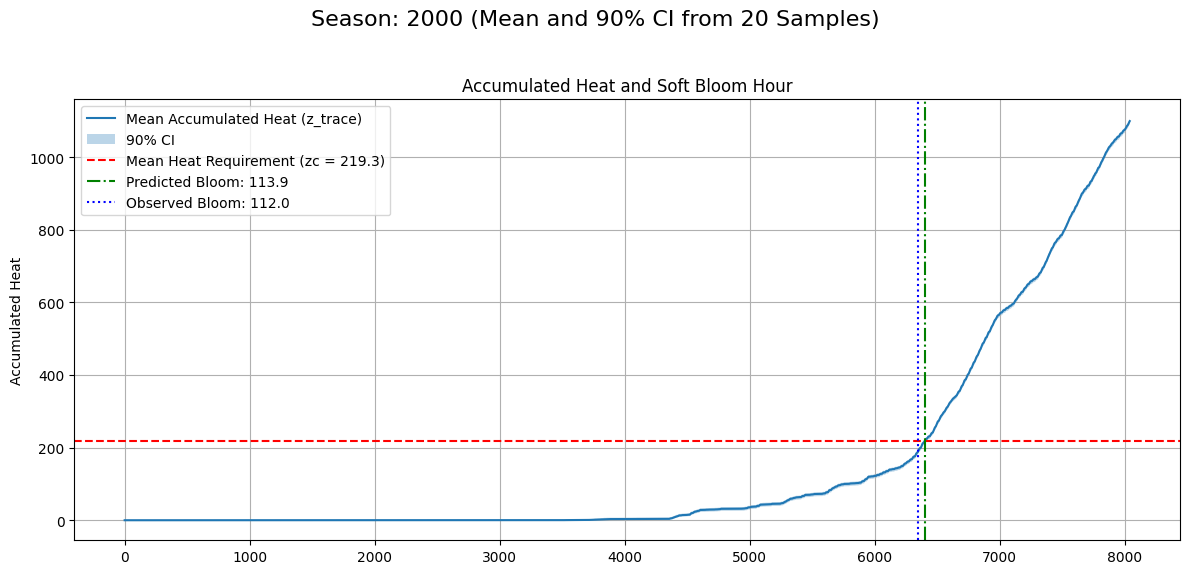

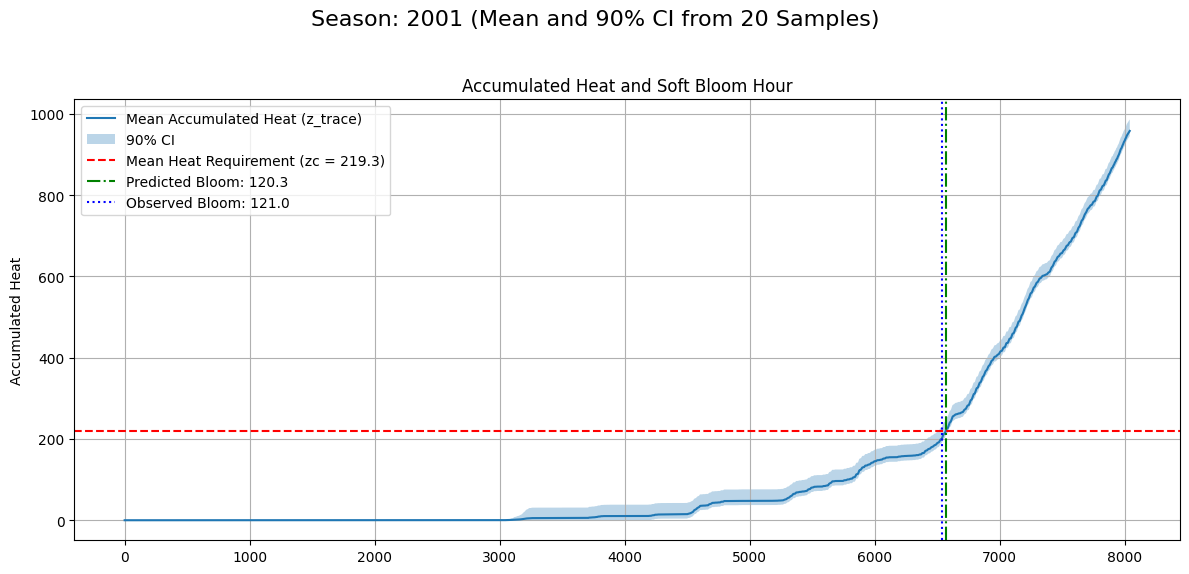

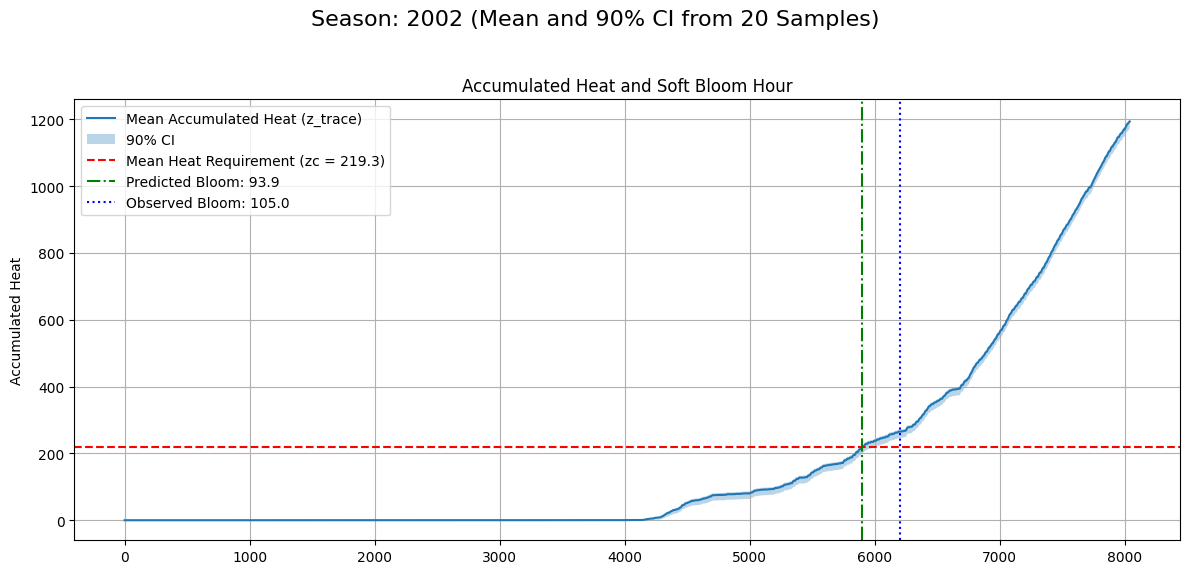

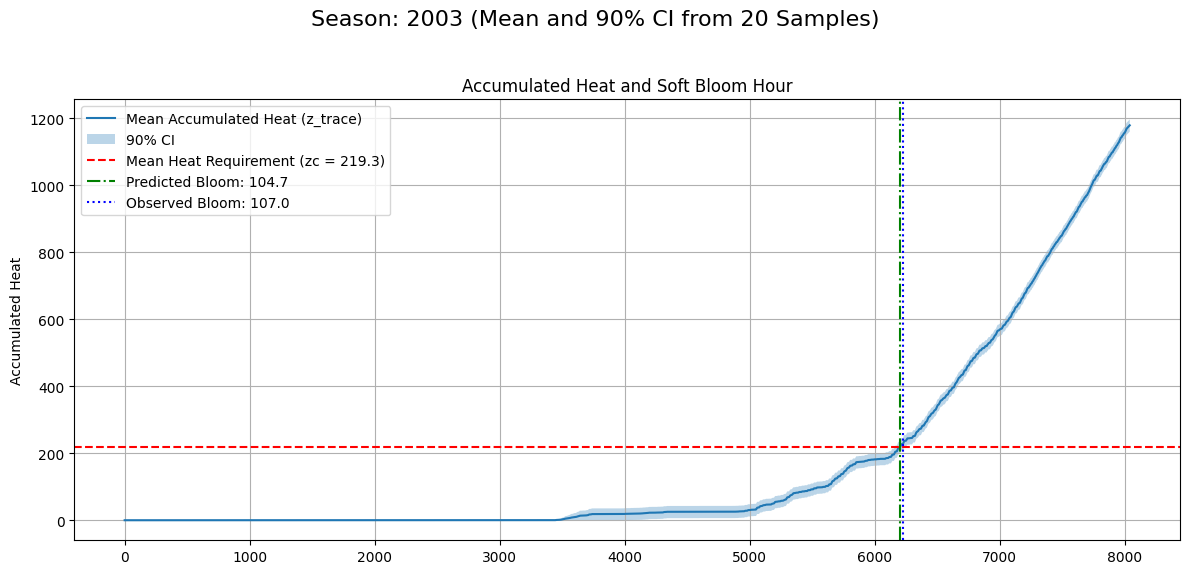

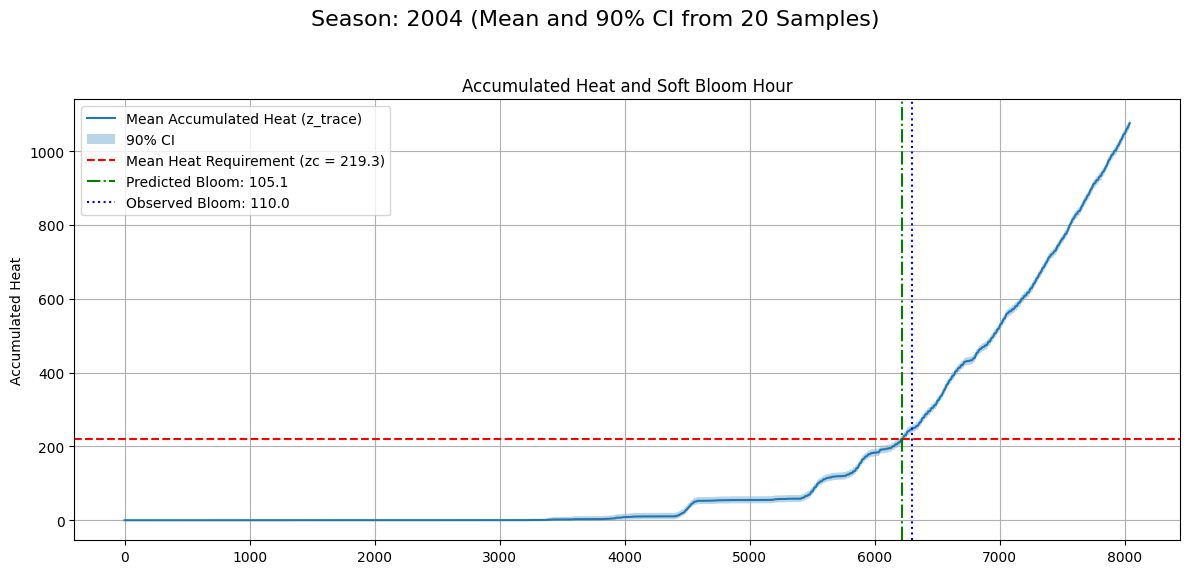

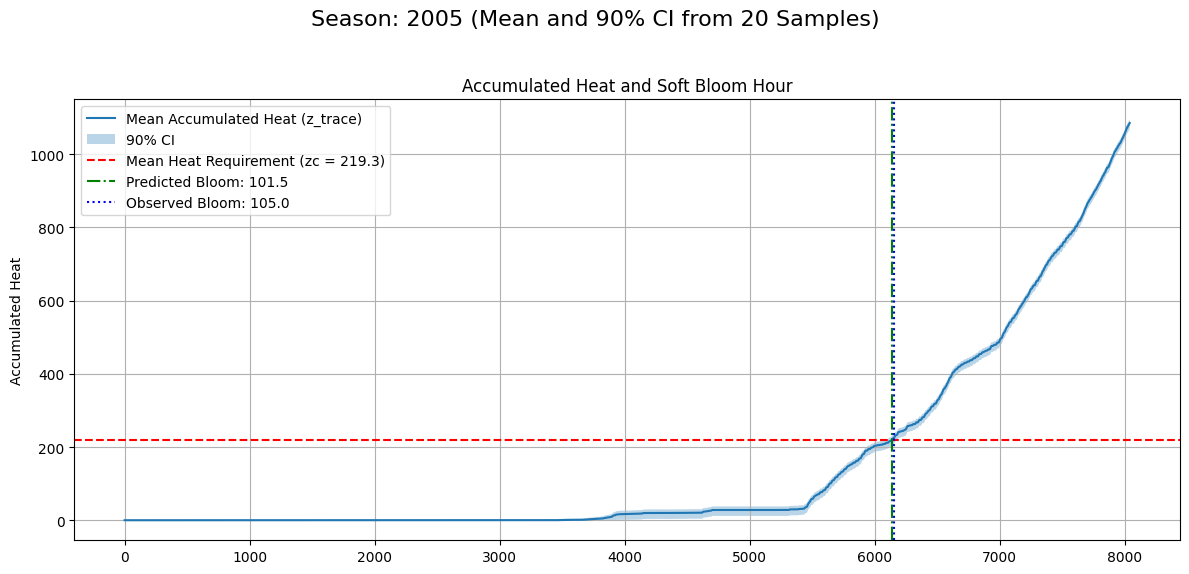

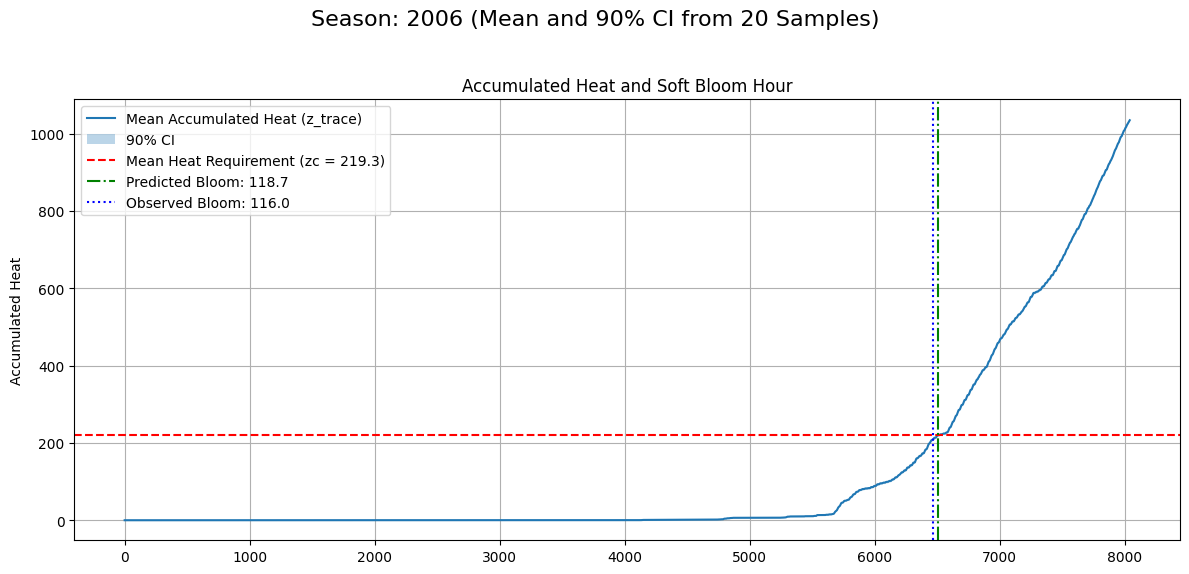

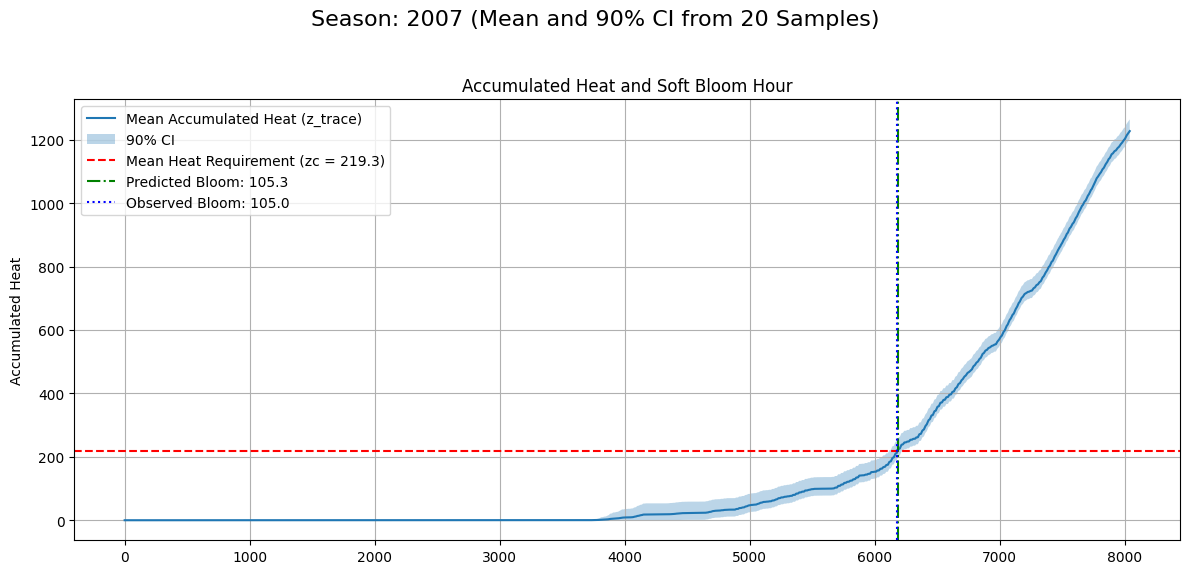

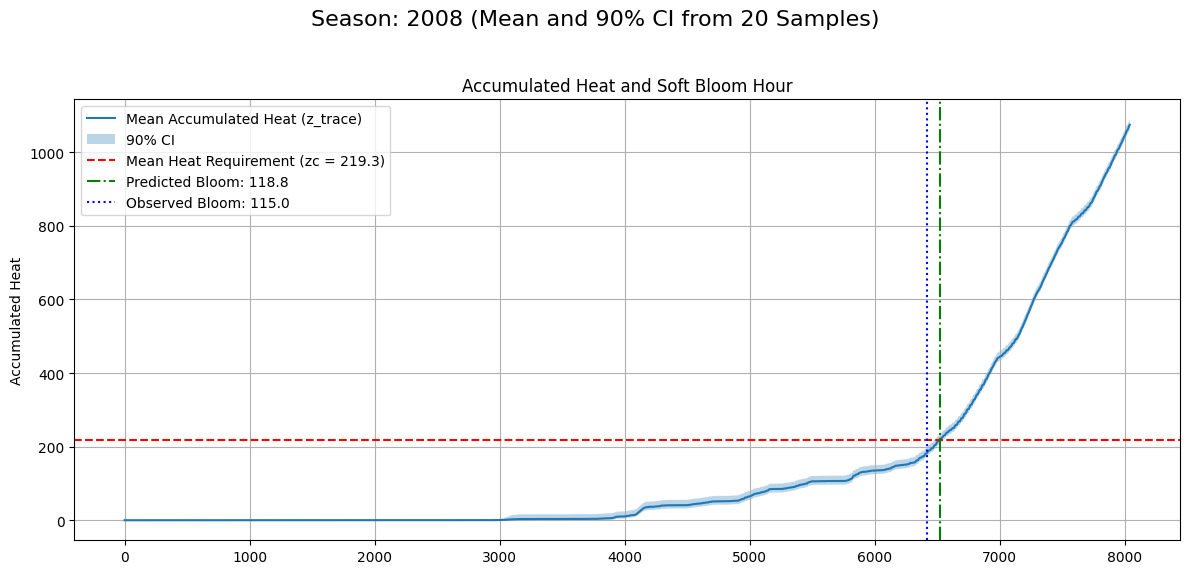

In [75]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np # Used for np.arange in the original example

# The soft_bloom_hour function from phenoflex_numpyro is designed for batched inputs.
# This helper is for single-season plotting if needed to re-calculate bloom hour.
def get_soft_bloom_hour_and_weights(z_trace_single_season, hours_single_season, zc_scalar, sharpness):
    # z_trace_single_season is (num_timesteps - 1,)
    # hours_single_season is (num_timesteps - 1,)
    # zc_scalar is scalar
    logits  = -sharpness * (z_trace_single_season - zc_scalar)**2
    # Numerically stable softmax
    logits  = logits - jnp.max(logits)
    weights = jnp.exp(logits)
    weights = weights / jnp.sum(weights)
    bloom_hour_val = jnp.dot(weights, hours_single_season)
    return bloom_hour_val, weights

# Assuming 'preds' is available from previous execution (cell plSeY2Y-C2NC)
# preds contains: 'z_trace' (num_samples, num_seasons, num_timesteps-1), 'y_trace' (num_samples, num_seasons, num_timesteps-1),
# 'zc' (num_samples,), 'bloom_doy_pred' (num_samples, num_seasons)
# 'times' (num_seasons, num_timesteps) and 'years' (num_seasons) are also available from plSeY2Y-C2NC

num_samples_in_preds = preds['z_trace'].shape[0]
num_seasons_in_preds = preds['z_trace'].shape[1]

# Calculate the mean zc from all samples for plotting consistency
mean_zc = preds['zc'].mean()

# Iterate through each season and plot
for i_season in range(num_seasons_in_preds):
    # Extract data for the current season across all samples
    z_trace_all_samples = preds['z_trace'][:, i_season, :] # Shape: (num_samples, num_timesteps-1)
    y_trace_all_samples = preds['y_trace'][:, i_season, :] # Shape: (num_samples, num_timesteps-1)
    bloom_doy_pred_all_samples = preds['bloom_doy_pred'][:, i_season] # Shape: (num_samples,)

    # Calculate mean and 90% credible interval (5th and 95th percentiles) for traces
    mean_z_trace = jnp.mean(z_trace_all_samples, axis=0)
    lower_z_trace = jnp.percentile(z_trace_all_samples, 5, axis=0)
    upper_z_trace = jnp.percentile(z_trace_all_samples, 95, axis=0)

    mean_y_trace = jnp.mean(y_trace_all_samples, axis=0)
    lower_y_trace = jnp.percentile(y_trace_all_samples, 5, axis=0)
    upper_y_trace = jnp.percentile(y_trace_all_samples, 95, axis=0)

    mean_bloom_doy_pred = jnp.mean(bloom_doy_pred_all_samples)

    # 'times' is from the prepare_seasons function and has shape (num_seasons, num_timesteps).
    # The z_trace and y_trace have num_timesteps-1 length, so we use times[:, 1:]
    hours_for_plotting = times[i_season, 1:]

    # Calculate bloom hour using the mean z_trace and mean zc
    # We re-calculate bloom hour using the mean trace for visualization.
    # Note: This is an approximation as the soft_bloom_hour is non-linear.
    bloom_hour_mean_z = get_soft_bloom_hour_and_weights(
        mean_z_trace, hours_for_plotting, mean_zc, sharpness=1.0
    )[0]

    season_year = years[i_season]

    # Get the observed bloom DOY for the current season
    observed_bloom_doy_val = bloom_doys[i_season]
    start_doy_val = start_doys[i_season]
    current_season_leap_year_info = leap_years[i_season-1] # This comes from check_leap_year([y - 1 for y in years])

    # Determine days in year for the season the bloom crosses over
    days_in_current_year_for_bloom = jnp.where(current_season_leap_year_info, 366.0, 365.0)

    # Adjust observed_bloom_doy if it wraps around to the next year
    adjusted_observed_bloom_doy = jnp.where(
        observed_bloom_doy_val < start_doy_val,
        observed_bloom_doy_val + days_in_current_year_for_bloom,
        observed_bloom_doy_val
    )

    # Calculate the observed bloom hour relative to the start of the season
    # The bloom_doy_pred is relative to start_doy, so convert observed_bloom_doy to relative hours.
    # `start_doys` is an array, so we need the element corresponding to the current season
    observed_bloom_hour = (adjusted_observed_bloom_doy - start_doy_val + 0.5) * 24.0

    # Create a single subplot instead of two
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
    fig.suptitle(f'Season: {season_year} (Mean and 90% CI from {num_samples_in_preds} Samples)', fontsize=16)

    # Subplot 1: Z-trace (Accumulated Heat) and Zc threshold
    ax1.plot(hours_for_plotting, mean_z_trace, label='Mean Accumulated Heat (z_trace)')
    ax1.fill_between(hours_for_plotting, lower_z_trace, upper_z_trace, alpha=0.3, label='90% CI')
    ax1.axhline(mean_zc, color='r', linestyle='--', label=f'Mean Heat Requirement (zc = {mean_zc:.1f})')
    ax1.axvline(bloom_hour_mean_z, color='g', linestyle='-.', label=f'Predicted Bloom: {mean_bloom_doy_pred:.1f}')
    ax1.axvline(observed_bloom_hour, color='b', linestyle=':', label=f'Observed Bloom: {observed_bloom_doy_val:.1f}') # Add observed bloom date
    ax1.set_ylabel('Accumulated Heat')
    ax1.set_title('Accumulated Heat and Soft Bloom Hour')
    ax1.legend()
    ax1.grid(True)

    # --- Start of commented out second subplot code ---
    # Subplot 2: Y-trace (Stable Chill Pool)
    # ax2.plot(hours_for_plotting, mean_y_trace, label='Mean Stable Chill Pool (y_trace)', color='purple')
    # ax2.fill_between(hours_for_plotting, lower_y_trace, upper_y_trace, color='purple', alpha=0.3, label='90% CI')
    # ax2.set_xlabel('Time (hours)')
    # ax2.set_ylabel('Stable Chill Pool')
    # ax2.set_title(f'Stable Chill Pool Accumulation. Mean Predicted Bloom DOY: {mean_bloom_doy_pred:.2f}')
    # ax2.legend()
    # ax2.grid(True)
    # --- End of commented out second subplot code ---

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

In [76]:
import jax.numpy as jnp

# Extract predicted and observed bloom DOYs
predicted_bloom_doys = preds["bloom_doy_pred"]
observed_bloom_doys = preds["bloom_doy"]

# Ensure observed_bloom_doys is broadcastable (it's already (1, num_seasons))
# If it were (num_seasons,) we'd need observed_bloom_doys[None, :]

# Calculate the difference for each sample and each season
differences = predicted_bloom_doys - observed_bloom_doys

#print("Differences (Predicted - Observed) per sample and season:\n", differences)


# Calculate the mean absolute difference across all samples and seasons
mean_abs_difference = jnp.mean(jnp.abs(differences))

print(f"\nMean Absolute Difference between predicted and observed flowering dates: {mean_abs_difference:.2f} days")


Mean Absolute Difference between predicted and observed flowering dates: 4.43 days


In [77]:
#differences

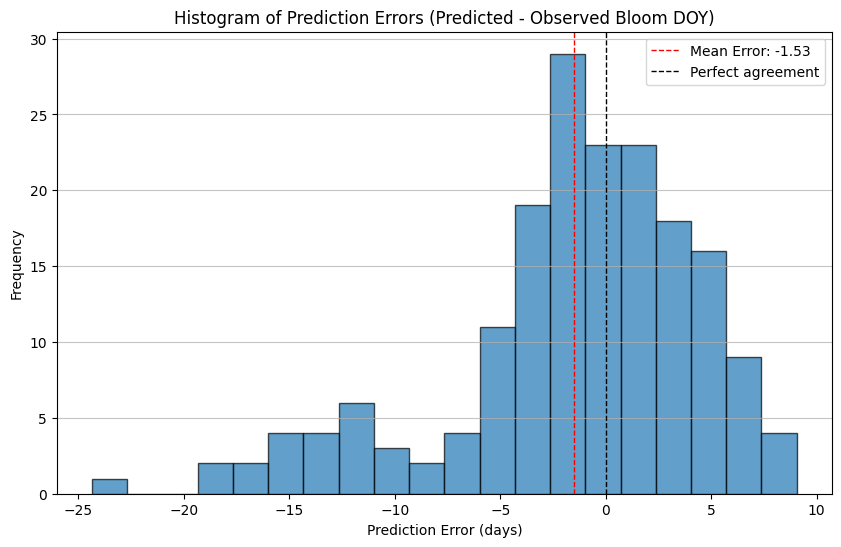

In [78]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Flatten the differences array to get all errors in a single 1D array
flat_differences = differences.flatten()

plt.figure(figsize=(10, 6))
plt.hist(flat_differences, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Prediction Errors (Predicted - Observed Bloom DOY)')
plt.xlabel('Prediction Error (days)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.axvline(jnp.mean(flat_differences), color='red', linestyle='dashed', linewidth=1, label=f'Mean Error: {jnp.mean(flat_differences):.2f}')
plt.axvline(0, color='black', linestyle='dashed', linewidth=1, label = 'Perfect agreement')
plt.legend()
plt.show()

Run the model with example temperature time series. the argument return_traces allows to return the modeled subprocesses. The function returns the bloomdate.

In [79]:
FIXED_PARAMS = dict(
    #yc=40.0,
    #zc=190.0,
    #s1=0.5,
    E0=4153.5,
    E1=12888.8,
    A0=139500.0,
    A1=2.567e18,
    Tf=4.0,
    slope=1.6,
    Tb=4.0,
    Tu=26.0,
    Tc=36.0,
    Delta=4.0,
)

# ── Run ───────────────────────────────────────────────────────────────────────

years = np.arange(2000,2009) # Changed from 2010 to 2009 to match bloom_doy_obs length
seasons = gen_season_list(KA_temp_hourly, years=years)
temps, times, start_doys, bloom_doys, leap_years = prepare_seasons(
    seasons, KA_bloom, years
)

print(f"Temps shape : {temps.shape}")
print(f"Times shape : {times.shape}")
print(f"Start DOYs  : {start_doys}")
print(f"Bloom DOYs  : {bloom_doys}")

conditioned_model = numpyro.handlers.condition(phenoflex_numpyro, data=FIXED_PARAMS)
predictive        = Predictive(conditioned_model, num_samples=1)
rng_key, _        = random.split(random.PRNGKey(1))

preds = predictive(
    rng_key,
    temp=temps, times=times, start_doy=start_doys,
    bloom_doy_obs=bloom_doys,
    sharpness=1, Imodel=0,
    leap_years=leap_years,
    return_traces=False,
)

Temps shape : (9, 8040)
Times shape : (9, 8040)
Start DOYs  : [213. 214. 213. 213. 213. 214. 213. 213. 213.]
Bloom DOYs  : [112. 121. 105. 107. 110. 105. 116. 105. 115.]


In [66]:
preds

{'A0': Array([139500.], dtype=float32, weak_type=True),
 'A1': Array([2.567e+18], dtype=float32, weak_type=True),
 'Delta': Array([4.], dtype=float32, weak_type=True),
 'E0': Array([4153.5], dtype=float32, weak_type=True),
 'E1': Array([12888.8], dtype=float32, weak_type=True),
 'Tb': Array([4.], dtype=float32, weak_type=True),
 'Tc': Array([36.], dtype=float32, weak_type=True),
 'Tf': Array([4.], dtype=float32, weak_type=True),
 'Tu': Array([26.], dtype=float32, weak_type=True),
 'bloom_doy': Array([[112., 121., 105., 107., 110., 105., 116., 105., 115.]], dtype=float32),
 'bloom_doy_pred': Array([[114.46683 , 121.579834,  93.565674, 107.60928 , 106.75964 ,
         104.55087 , 120.04733 , 106.60855 , 119.55228 ]], dtype=float32),
 's1': Array([0.67916626], dtype=float32),
 'sigma': Array([4.4829507], dtype=float32),
 'slope': Array([1.6], dtype=float32, weak_type=True),
 'yc': Array([74.477516], dtype=float32),
 'zc': Array([223.28624], dtype=float32)}

This functions is wrapping the model so that the MCMC sanling can uinteract with it

In [80]:
def run_inference(model, args, rng_key, dat):
    start = time.time()
    sampler = numpyro.infer.NUTS(model)
    mcmc = numpyro.infer.MCMC(
        sampler,
        num_warmup=args['num_warmup'],
        num_samples=args['num_samples'],
        num_chains=args['num_chains'],
        progress_bar=False if "NUMPYRO_SPHINXBUILD" in os.environ else True,
    )
    mcmc.run(rng_key, **dat)
    mcmc.print_summary()
    az_mcmc = az.from_numpyro(mcmc)
    print("\nMCMC elapsed time:", time.time() - start)
    return mcmc, mcmc.get_samples(), az_mcmc

Run the mcmc sampling with a random sample of yc, zc, s1 as a starting point?

In [81]:
print('dimensions of temps: ', temps.shape)
print('dimensions of times: ',times.shape)
print('dimensions of start_doy: ',start_doys.shape)
print('dimensions of bloom_doys: ',bloom_doys.shape)

dimensions of temps:  (9, 8040)
dimensions of times:  (9, 8040)
dimensions of start_doy:  (9,)
dimensions of bloom_doys:  (9,)


In [82]:
# Prepare the 'dat' dictionary for phenoflex_numpyro
# Reusing the data prepared in previous cells (e.g., from plSeY2Y-C2NC)
dat_phenoflex = {
    'temp': temps,
    'times': times,
    'start_doy': start_doys,
    'bloom_doy_obs': bloom_doys,
    'leap_years': leap_years,
    'sharpness': 1, # Using the same sharpness as in the predictive run
    'Imodel': 0    # Using the same Imodel as in the predictive run
}

# Define args for run_inference
args_phenoflex = {}
args_phenoflex['num_warmup'] = 1000
args_phenoflex['num_samples'] = 1000
args_phenoflex['num_chains'] = 2

# Set the model to phenoflex_numpyro
model_phenoflex = phenoflex_numpyro

# Condition the model with fixed parameters as done previously (e.g., in qmpen104LyfF)
conditioned_model_phenoflex = numpyro.handlers.condition(model_phenoflex, data=FIXED_PARAMS)

# Run the inference
mcmc_phenoflex, mcmc_samples_phenoflex, az_mcmc_phenoflex = run_inference(conditioned_model_phenoflex, args_phenoflex, rng_key, dat_phenoflex)

/tmp/ipykernel_2676/3796674854.py:4: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = numpyro.infer.MCMC(
sample: 100%|██████████| 2000/2000 [1:45:33<00:00,  3.17s/it, 51 steps of size 5.19e-02. acc. prob=0.80]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
        s1      0.26      0.30      0.03      0.00      0.73      1.21      2.14
     sigma     17.90     14.92     17.92      1.80     34.21      1.00     14.47
        yc     70.57     15.42     72.55     46.59     90.76      1.30      1.84
        zc    102.32    107.93     83.84    -13.14    219.70      1.00     13.25

Number of divergences: 0

MCMC elapsed time: 7954.5762367248535


Rhat is kinda high, so that is not great. Also the estimated heatz requirement is very low (and the sd is high)

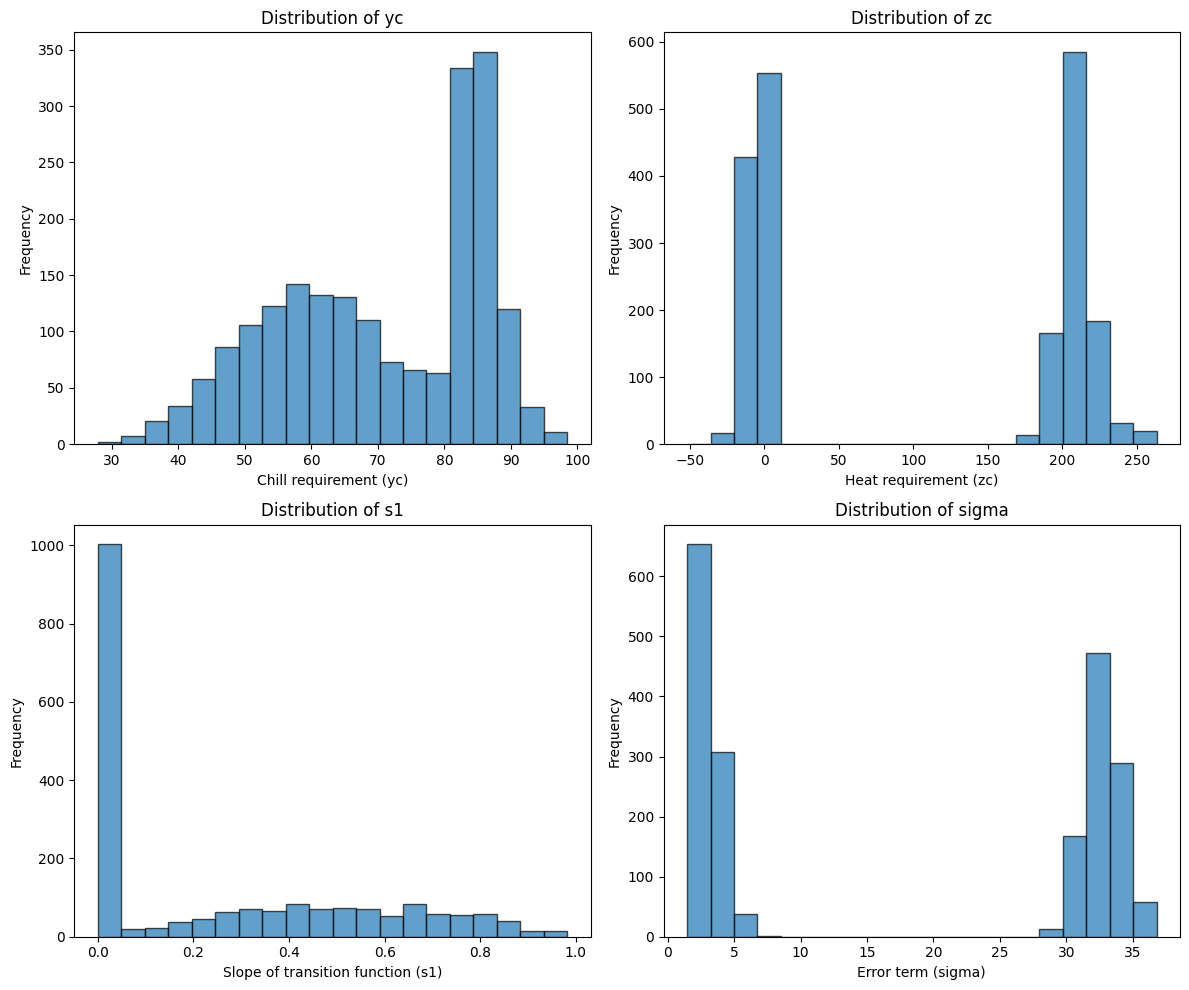

In [91]:
flat_yc = mcmc_samples_phenoflex['yc'].flatten()
flat_zc = mcmc_samples_phenoflex['zc'].flatten()
flat_s1 = mcmc_samples_phenoflex['s1'].flatten()
flat_sigma = mcmc_samples_phenoflex['sigma'].flatten()

#plt.figure(figsize=(10, 6))
#plt.hist(flat_differences, bins=20, edgecolor='black', alpha=0.7)
#plt.title('Histogram of Prediction Errors (Predicted - Observed Bloom DOY)')
#plt.xlabel('Prediction Error (days)')
#plt.ylabel('Frequency')
#plt.grid(axis='y', alpha=0.75)
#plt.axvline(jnp.mean(flat_differences), color='red', linestyle='dashed', linewidth=1, label=f'Mean Error: {jnp.mean(flat_differences):.2f}')
#plt.axvline(0, color='black', linestyle='dashed', linewidth=1, label = 'Perfect agreement')
#plt.legend()
#plt.show()


fig, axes = plt.subplots(2, 2, figsize=(12, 10)) # Increased figsize for better visibility

# First plot (yc)
axes[0, 0].hist(flat_yc, bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Chill requirement (yc)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of yc')

# Second plot (zc)
axes[0, 1].hist(flat_zc, bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Heat requirement (zc)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of zc')

# Third plot (s1)
axes[1, 0].hist(flat_s1, bins=20, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Slope of transition function (s1)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of s1')

# Fourth plot (sigma)
axes[1, 1].hist(flat_sigma, bins=20, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Error term (sigma)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of sigma')

plt.tight_layout()
plt.show()

In [72]:
from numpyro.infer.util import potential_energy
import jax

test_params = {"yc": 65.0, "zc": 220.0, "s1": 0.5, "sigma": 3.0}

pe = potential_energy(conditioned_model_phenoflex, (), dat_phenoflex, test_params)
print("Potential energy:", pe)  # Must be finite

grads = jax.grad(potential_energy, argnums=3)(
    conditioned_model_phenoflex, (), dat_phenoflex, test_params
)
for k, v in grads.items():
    print(f"grad {k}: {v}")

Potential energy: 143.86293
grad s1: nan
grad sigma: 52.31631088256836
grad yc: nan
grad zc: -0.0024129764642566442


so the gradient for s1 and yc is nan, that might be the reason why the algorithm cannot find initial parameters

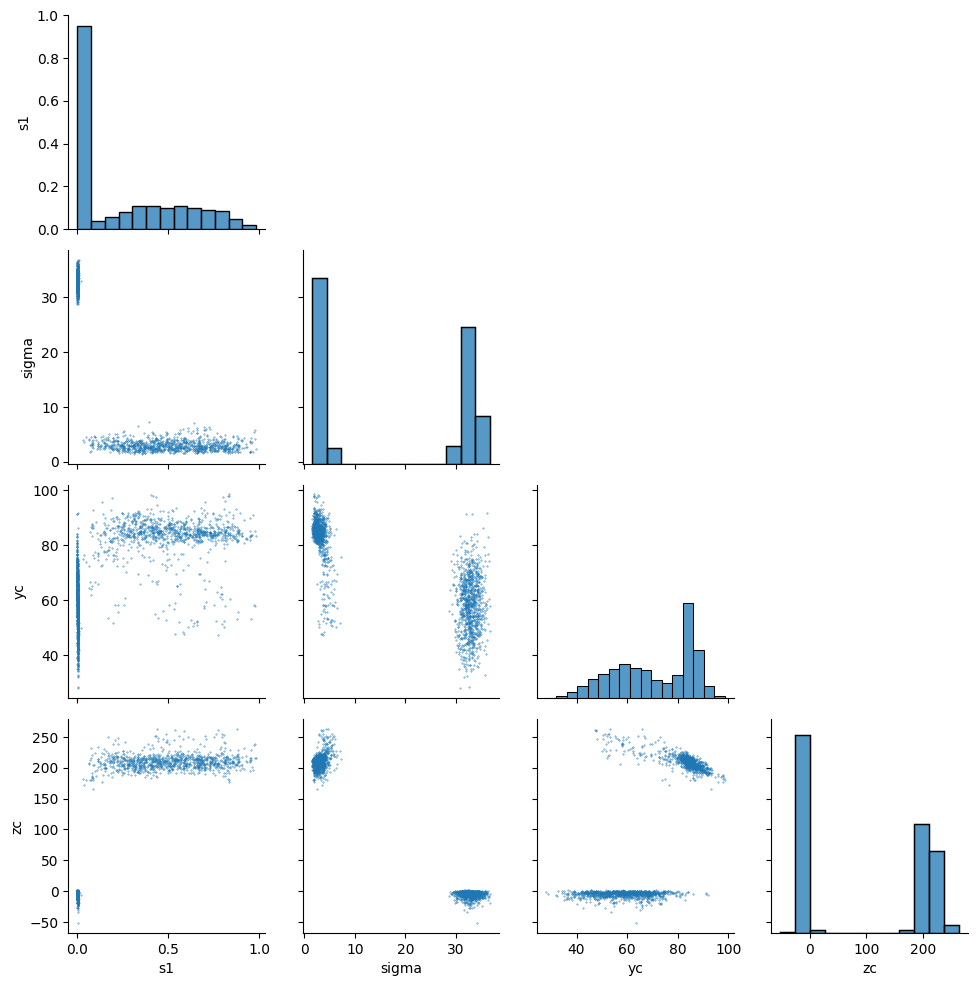

In [101]:
import seaborn as sns
import pandas as pd

# Plot the posterior
plot_data = {
    's1': mcmc_samples_phenoflex['s1'],
    'sigma': mcmc_samples_phenoflex['sigma'],
    'yc': mcmc_samples_phenoflex['yc'],
    'zc': mcmc_samples_phenoflex['zc']
}
g = sns.PairGrid(pd.DataFrame.from_dict(plot_data))
g.map_lower(plt.scatter,s=0.1)
g.map_diag(sns.histplot, lw=3, legend=False)
# Hide upper plots of grid
def hide_current_axis(*args, **kwds):
    plt.gca().set_visible(False)
g.map_upper(hide_current_axis);

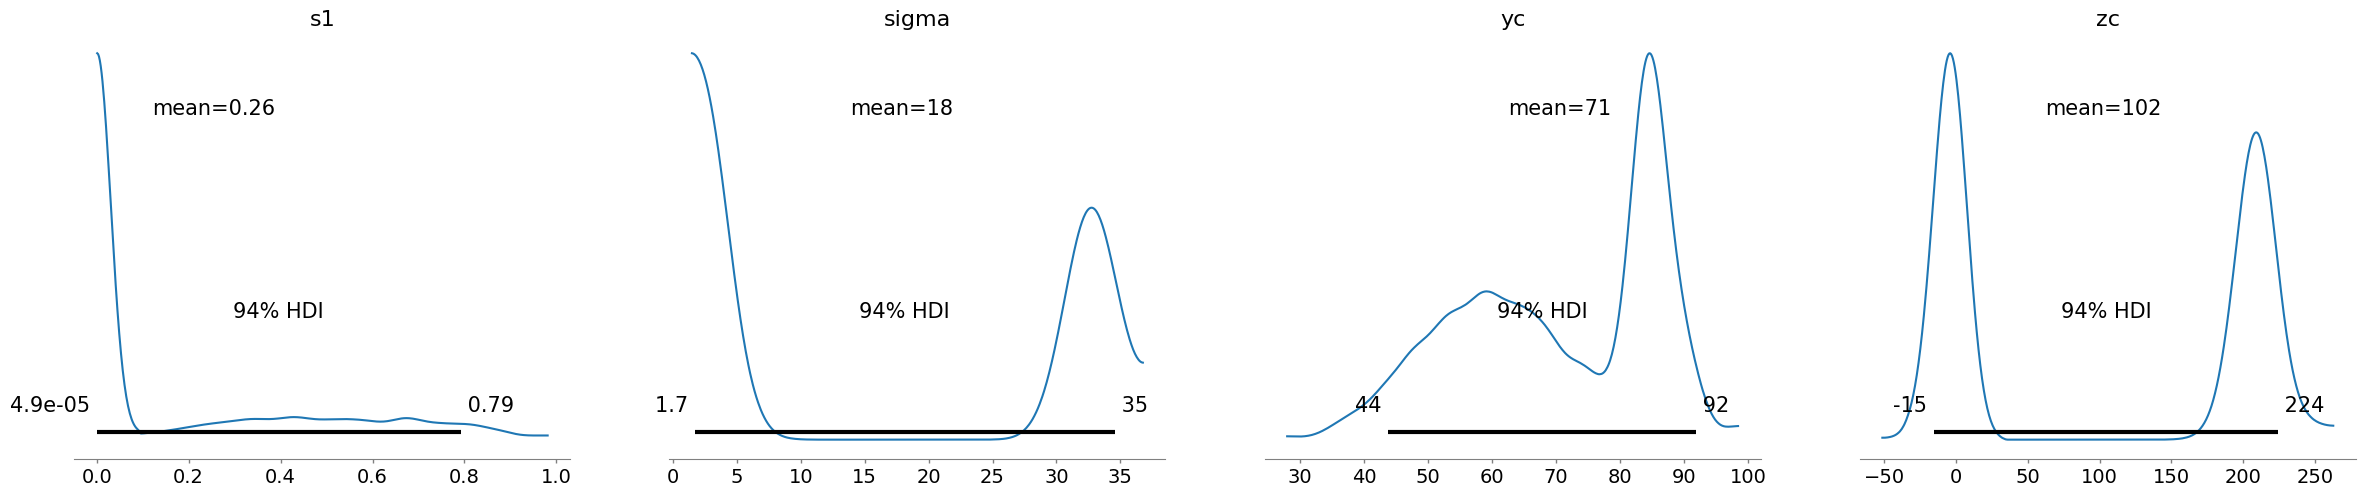

In [102]:
az.plot_posterior(plot_data);

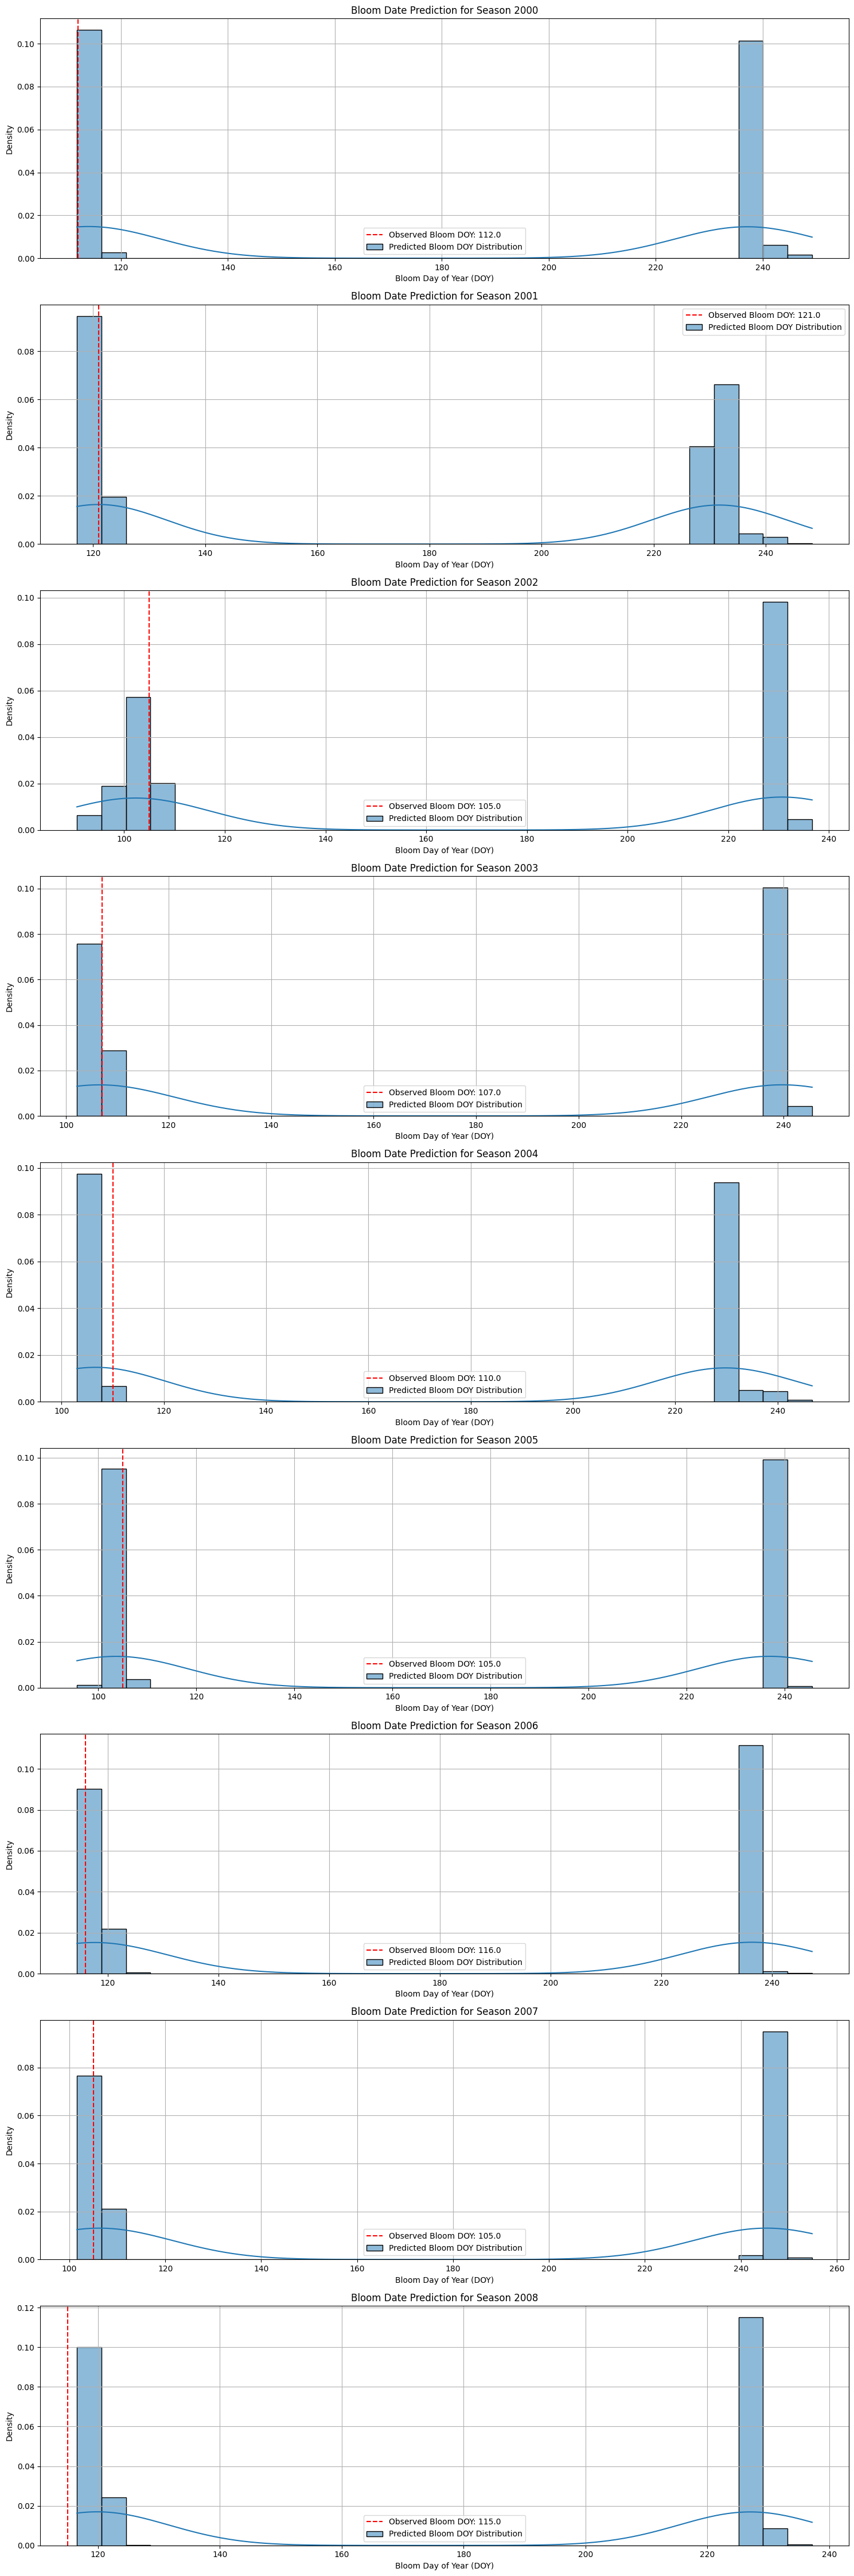

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import jax.numpy as jnp

# Get predicted bloom DOYs from MCMC samples
predicted_bloom_doys_mcmc = mcmc_samples_phenoflex['bloom_doy_pred'] # Shape: (num_samples, num_seasons)

# Get observed bloom DOYs and years from the data preparation step
# These variables (bloom_doys, years) should be available from previous cells like plSeY2Y-C2NC or qmpen104LyfF
# If not, you might need to re-run the cell where they are defined.

num_seasons = predicted_bloom_doys_mcmc.shape[1]

plt.figure(figsize=(15, 5 * num_seasons))

for i_season in range(num_seasons):
    predicted_for_season = predicted_bloom_doys_mcmc[:, i_season]
    observed_for_season = bloom_doys[i_season]
    year_for_season = years[i_season]

    plt.subplot(num_seasons, 1, i_season + 1)
    sns.histplot(predicted_for_season, kde=True, stat='density', bins=30, label='Predicted Bloom DOY Distribution')
    plt.axvline(observed_for_season, color='red', linestyle='--', label=f'Observed Bloom DOY: {observed_for_season:.1f}')
    plt.title(f'Bloom Date Prediction for Season {year_for_season}')
    plt.xlabel('Bloom Day of Year (DOY)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [111]:
print(seasons[0].head())
print(seasons[0].tail())

        Temp  JDay  Year
13848  13.74   213  1999
13849  12.84   213  1999
13850  12.07   213  1999
13851  11.41   213  1999
13852  10.81   213  1999
        Temp  JDay  Year
21883  17.64   182  2000
21884  16.79   182  2000
21885  15.90   182  2000
21886  15.36   182  2000
21887  14.99   182  2000


The crazy-late predictions are actually crazy-early predictions where the model uses negative or close to zero heat requirements and immediately returns a bloom date. Problem is, that this bloom date is kinda close (not really though) as the actual bloom date and gradually increasing it makes prediction errro worse, because the predicted bloom date increases. (and thus it distances from the observation).

quick fix: return bloom dates before Dec31 as negative values. then the direction of bloom date is monotonous